# The Computer Vision Project — CIFAR-10 Classification

This notebook works through the case introduced in *The Computer Vision Project*:
- **Task:** Classification problem with 10 classes (CIFAR-10 dataset)
- **Images:** Colorful (RGB), 32x32 in size
- **Data:** 50k images available for training, 10k for testing
- **Classes are mutually exclusive** (e.g. no overlap between `automobile` and `truck`)

We'll go through the same essential steps as the `CNN_classification` walkthrough: load & explore the data, preprocess it, build a model on top of a pretrained network, train it, and evaluate its performance.

## 1. Setup

In [1]:
!pip install keras tensorflow

zsh:1: command not found: pip


In [2]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Load the Data

CIFAR-10 is available directly through `tensorflow.keras.datasets`.

In [3]:
# Data load
(train_imgs, train_labels), (test_imgs, test_labels) = cifar10.load_data()

## 3. EDA (Exploratory Data Analysis)

In [4]:
# Class names, in label order (0-9)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [5]:
# Data Checkout
print("The number of training examples is: ", train_imgs.shape[0])
print("The number of test examples is: ", test_imgs.shape[0])
print("The size of every img is: ", train_imgs.shape[1:])
num_classes = len(np.unique(train_labels))
print("The number of classes is: ", num_classes)

The number of training examples is:  50000
The number of test examples is:  10000
The size of every img is:  (32, 32, 3)
The number of classes is:  10


In [6]:
# cifar10 labels come back as shape (n, 1) - flatten them to (n,)
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

Text(0.5, 1.0, 'Ground truth is: deer')

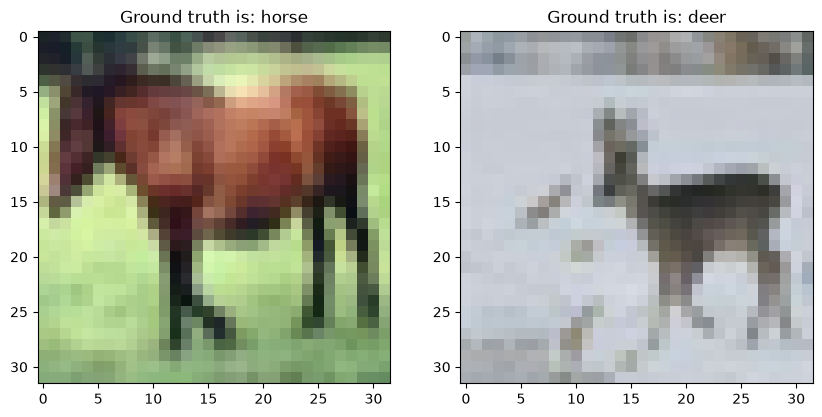

In [7]:
# printing out some samples
figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(train_imgs[7, :, :])
ax1.set_title("Ground truth is: {}".format(class_names[train_labels[7]]))

ax2.imshow(train_imgs[20, :, :])
ax2.set_title("Ground truth is: {}".format(class_names[train_labels[20]]))

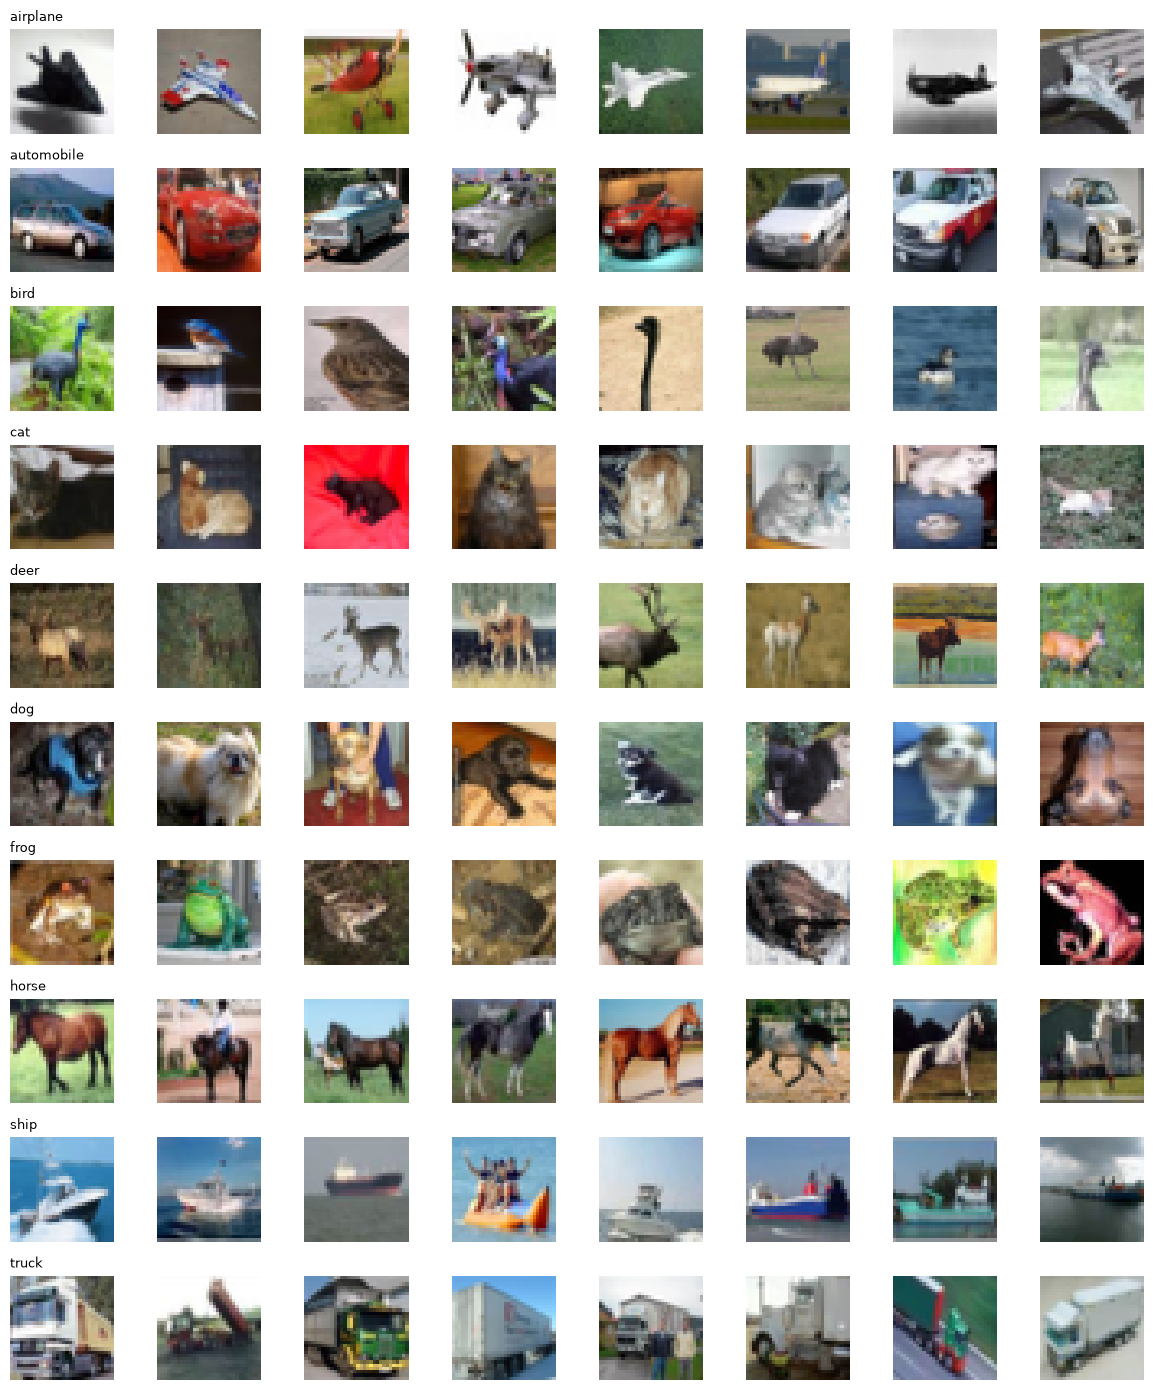

In [8]:
# One row of sample images per class, like in the project slides
fig, axes = plt.subplots(num_classes, 8, figsize=(12, 14))

for class_idx in range(num_classes):
    class_img_indices = np.where(train_labels == class_idx)[0][:8]
    for col, img_idx in enumerate(class_img_indices):
        ax = axes[class_idx, col]
        ax.imshow(train_imgs[img_idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_names[class_idx])
    axes[class_idx, 0].set_title(class_names[class_idx], loc='left', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Limiting the Dataset

Using all 50k training images gives the best performance but takes more time and compute. **To save time, let's limit the training data to 10k only.** (Note: the test set already only has 10k images, so it doesn't need limiting.)

In [9]:
# Getting only 10k from the training portion of data
n = 10000

train_imgs = train_imgs[:n]
train_labels = train_labels[:n]

## 5. Data Preprocessing

### 5.1 Normalize pixel values
Neural nets expect normalized images. We move pixel values from the `0..255` range to `0..1`.

In [10]:
# Convert images to float and scale from 0..255 to 0..1
train_data = train_imgs.astype('float32')
test_data = test_imgs.astype('float32')

train_data /= 255
test_data /= 255

### 5.2 One-hot encode the labels

In [11]:
# Converting labels to one-hot encoding form
train_labels_one_hot = to_categorical(train_labels, num_classes)
test_labels_one_hot = to_categorical(test_labels, num_classes)

In [12]:
print("Before encoding", train_labels[5])
print("After encoding", train_labels_one_hot[5])

Before encoding 1
After encoding [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


## 6. Model Selection

### 6.1 Import a pretrained network

We use `ResNet50` pretrained on ImageNet as our feature extractor:
- `weights='imagenet'` — import the network pretrained on ImageNet
- `include_top=False` — drop off the top (classification) part of the network
- `input_shape` — matches our CIFAR-10 image size, `(32, 32, 3)`

In [13]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Freeze the pretrained base so we only train the new top layers
base_model.trainable = False

### 6.2 Build the top of the network

We add:
- A `GlobalAveragePooling2D` layer to turn the feature maps into a single vector
- Two hidden `Dense` layers (128, then 64 neurons — powers of two, first layer larger)

In [14]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)

### 6.3 Add the output layer

The output layer has one neuron per class, with a `softmax` activation for multi-class classification.

In [15]:
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,858,890 (91.01 MB)

 Trainable params: 271,178 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 7. Compile, Train, Evaluate

### 7.1 Compile the model

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 7.2 Train the model

In [17]:
history = model.fit(
    train_data, train_labels_one_hot,
    batch_size=64,
    epochs=20,
    verbose=1,
    validation_data=(test_data, test_labels_one_hot)
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - accuracy: 0.1536 - loss: 2.2490 - val_accuracy: 0.2207 - val_loss: 2.1235
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.2219 - loss: 2.1000 - val_accuracy: 0.2372 - val_loss: 2.0482
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.2455 - loss: 2.0324 - val_accuracy: 0.2532 - val_loss: 1.9958
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.2655 - loss: 1.9793 - val_accuracy: 0.2636 - val_loss: 1.9854
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.2774 - loss: 1.9603 - val_accuracy: 0.2895 - val_loss: 1.9698
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - accuracy: 0.2932 - loss: 1.9226 - val_accuracy: 0.2801 - val_loss: 1.9401
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - accuracy: 0.2958 - loss: 1.9066 - val_accuracy: 0.3141 - val_loss: 1.8886
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.3167 - loss: 1

### 7.3 Evaluate on the test data

In [18]:
[test_loss, test_acc] = model.evaluate(test_data, test_labels_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.3682 - loss: 1.7565
Evaluation result on Test Data : Loss = 1.7564865350723267, accuracy = 0.36820000410079956


## 8. Visualizing Training Performance

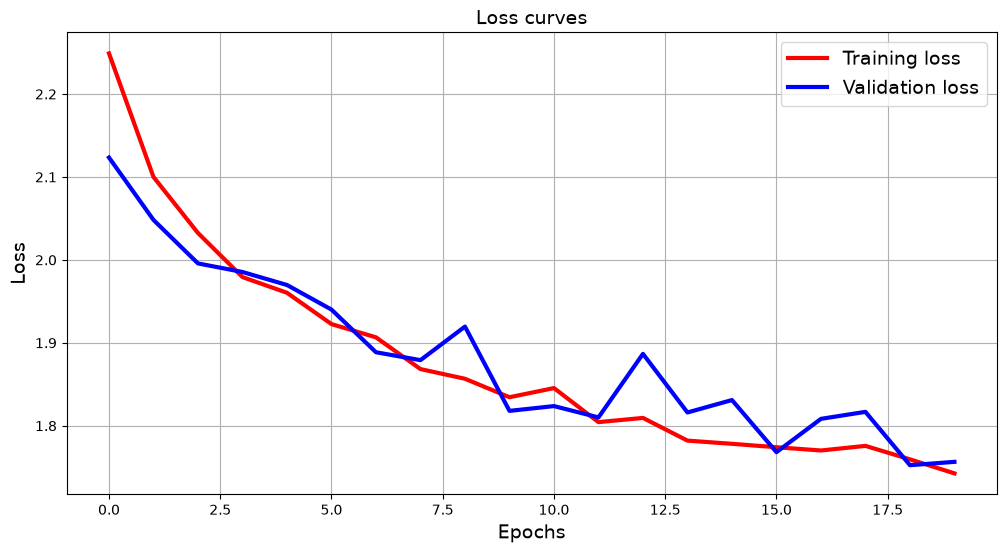

In [19]:
plt.figure(figsize=[12, 6])
plt.plot(history.history['loss'], 'r', linewidth=3.0)
plt.plot(history.history['val_loss'], 'b', linewidth=3.0)
plt.legend(['Training loss', 'Validation loss'], fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Loss curves', fontsize=14)
plt.grid()

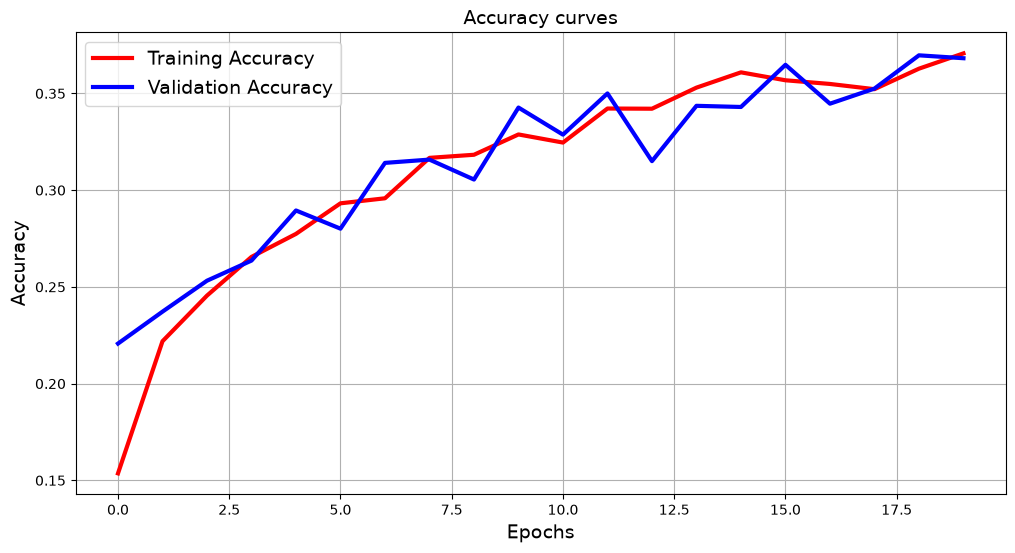

In [20]:
plt.figure(figsize=[12, 6])
plt.plot(history.history['accuracy'], 'r', linewidth=3.0)
plt.plot(history.history['val_accuracy'], 'b', linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Accuracy curves', fontsize=14)
plt.grid()

## 9. Making Predictions

In [21]:
# Predict on the full test set
test_predictions = model.predict(test_data)
predicted_labels = np.argmax(test_predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


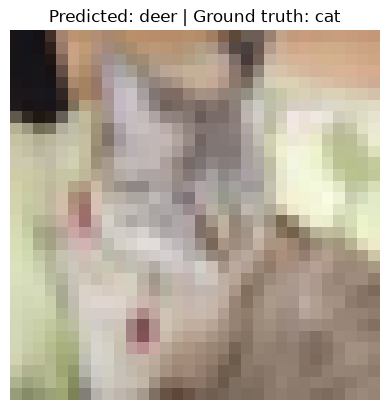

In [22]:
# Check a single prediction against ground truth
idx = 8
single_pred = model.predict(test_data[[idx], :])
predicted_class = np.argmax(single_pred)

plt.imshow(test_imgs[idx])
plt.title(f"Predicted: {class_names[predicted_class]} | Ground truth: {class_names[test_labels[idx]]}")
plt.axis('off')
plt.show()

## 11. Alternative Pretrained Base: `EfficientNet`

Next step from the list above: let's swap `ResNet50` for `EfficientNet` and follow the exact same steps, to see if we get better accuracy.

We use `EfficientNetB0` (the smallest, fastest variant) pretrained on ImageNet as our feature extractor:
- `weights='imagenet'` — import the network pretrained on ImageNet
- `include_top=False` — drop off the top (classification) part of the network
- `input_shape` — matches our CIFAR-10 image size, `(32, 32, 3)`

In [38]:
from tensorflow.keras.applications import EfficientNetB0

### 11.1 Build the model

Same architecture as before — a frozen pretrained base plus a small head:
- A `GlobalAveragePooling2D` layer to turn the feature maps into a single vector
- Two hidden `Dense` layers (128, then 64 neurons)
- A `softmax` output layer with one neuron per class

In [39]:
efficient_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Freeze the pretrained base so we only train the new top layers
efficient_base.trainable = False

x = efficient_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

efficient_model = Model(inputs=efficient_base.input, outputs=predictions)
efficient_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 32, 32, 3) │          0 │ input_layer_4[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 32, 32, 3) │          7 │ rescaling_4[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 32, 32, 3) │          0 │ normalization_2[… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 33, 33, 3) │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 16, 16,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 16, 16,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 16, 16,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 16, 16,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 16, 16,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 16, 16,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 16, 16,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 16, 16,    │        512 │ block1a_se_excit

 Total params: 4,222,445 (16.11 MB)

 Trainable params: 172,874 (675.29 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 11.2 Compile the model

In [40]:
efficient_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 11.3 Train the model

In [ ]:
efficient_history = efficient_model.fit(
    train_data, train_labels_one_hot,
    batch_size=64,
    epochs=20,
    verbose=1,
    validation_data=(test_data, test_labels_one_hot)
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.0987 - loss: 2.3157 - val_accuracy: 0.1000 - val_loss: 2.3083
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.0987 - loss: 2.3049 - val_accuracy: 0.1000 - val_loss: 2.3058
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.0980 - loss: 2.3040 - val_accuracy: 0.1000 - val_loss: 2.3039
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.0965 - loss: 2.3041 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1005 - loss: 2.3025 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1004 - loss: 2.3024 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.0994 - loss: 2.3024 - val_accuracy: 0.1000 - val_loss: 2.3029
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1004 - loss: 2.3024 - val_acc

### 11.4 Evaluate on the test data

In [ ]:
[efficient_test_loss, efficient_test_acc] = efficient_model.evaluate(test_data, test_labels_one_hot)
print("EfficientNet evaluation result on Test Data : Loss = {}, accuracy = {}".format(efficient_test_loss, efficient_test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1000 - loss: 2.3030
EfficientNet evaluation result on Test Data : Loss = 2.302989959716797, accuracy = 0.10000000149011612


### 11.5 Visualizing Training Performance

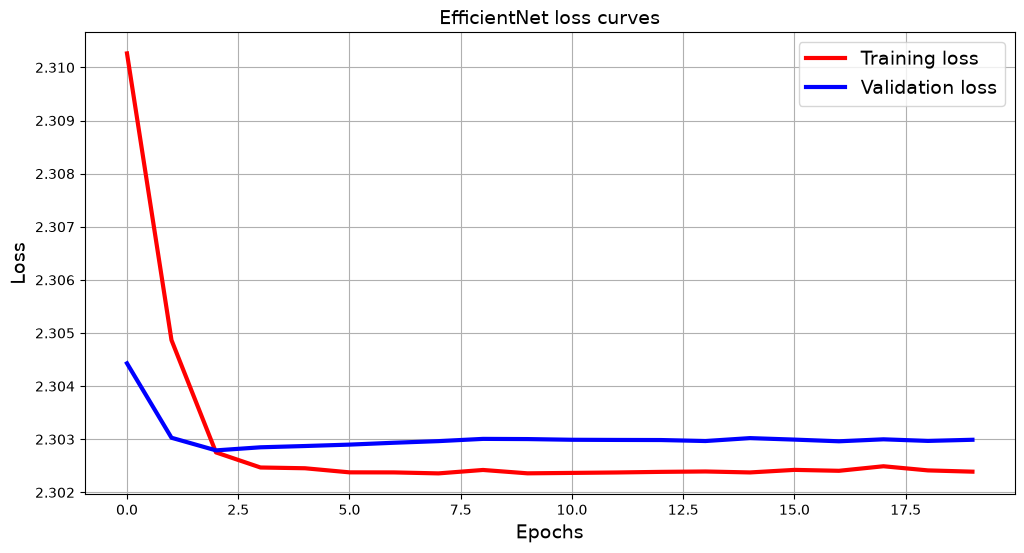

In [ ]:
plt.figure(figsize=[12, 6])
plt.plot(efficient_history.history['loss'], 'r', linewidth=3.0)
plt.plot(efficient_history.history['val_loss'], 'b', linewidth=3.0)
plt.legend(['Training loss', 'Validation loss'], fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('EfficientNet loss curves', fontsize=14)
plt.grid()

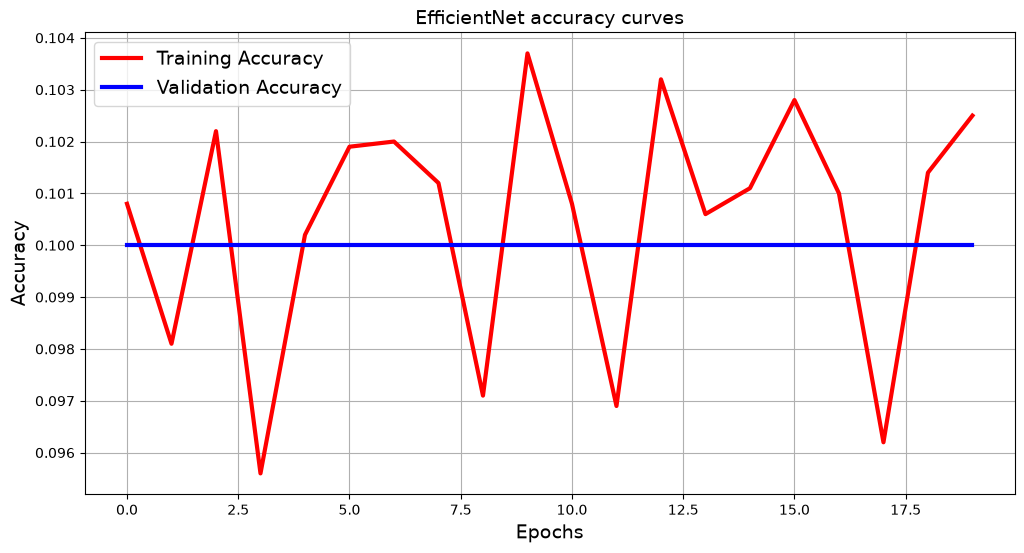

In [ ]:
plt.figure(figsize=[12, 6])
plt.plot(efficient_history.history['accuracy'], 'r', linewidth=3.0)
plt.plot(efficient_history.history['val_accuracy'], 'b', linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('EfficientNet accuracy curves', fontsize=14)
plt.grid()

### 11.6 Making Predictions

In [ ]:
# Predict on the full test set
efficient_test_predictions = efficient_model.predict(test_data)
efficient_predicted_labels = np.argmax(efficient_test_predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


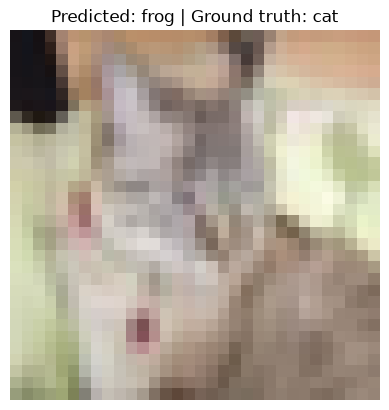

In [ ]:
# Check a single prediction against ground truth
idx = 8
efficient_single_pred = efficient_model.predict(test_data[[idx], :])
efficient_predicted_class = np.argmax(efficient_single_pred)

plt.imshow(test_imgs[idx])
plt.title(f"Predicted: {class_names[efficient_predicted_class]} | Ground truth: {class_names[test_labels[idx]]}")
plt.axis('off')
plt.show()

### 11.7 Comparison: `ResNet50` vs `EfficientNet`

In [ ]:
print("ResNet50 test accuracy   : {:.4f}".format(test_acc))
print("EfficientNet test accuracy: {:.4f}".format(efficient_test_acc))

if efficient_test_acc > test_acc:
    print("EfficientNet does better than ResNet50 by {:.4f}.".format(efficient_test_acc - test_acc))
elif efficient_test_acc < test_acc:
    print("ResNet50 does better than EfficientNet by {:.4f}.".format(test_acc - efficient_test_acc))
else:
    print("Both pretrained bases give the same test accuracy.")

ResNet50 test accuracy   : 0.3682
EfficientNet test accuracy: 0.1000
ResNet50 does better than EfficientNet by 0.2682.


### 12. Sequential-API variant

Instead of the Functional API (`inputs=...`, `outputs=...`), we can build the same model with `tf.keras.Sequential` by passing the frozen `EfficientNetB0` base in as the first layer:
- `layers[0]` is the pretrained base, so we freeze it by setting `trainable = False`
- Same head as before (GlobalAveragePooling2D + Dense 128 + Dense 64 + softmax)

In [ ]:
from tensorflow.keras.models import Sequential

efficient_model_seq = Sequential([
    EfficientNetB0(weights='imagenet', include_top=False,
                   input_shape=(32, 32, 3)),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Freeze the pretrained base (first layer) so we only train the new top layers
efficient_model_seq.layers[0].trainable = False

efficient_model_seq.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,222,445 (16.11 MB)

 Trainable params: 172,874 (675.29 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 12.1 Compile, Train, Evaluate the Sequential model

In [ ]:
efficient_model_seq.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
efficient_seq_history = efficient_model_seq.fit(
    train_data, train_labels_one_hot,
    batch_size=64,
    epochs=10,
    verbose=1,
    validation_data=(test_data, test_labels_one_hot)
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.0988 - loss: 2.3109 - val_accuracy: 0.1000 - val_loss: 2.3056
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.1004 - loss: 2.3046 - val_accuracy: 0.1000 - val_loss: 2.3046
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.0984 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3031
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.1029 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.1030 - loss: 2.3025 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.1007 - loss: 2.3024 - val_accuracy: 0.1000 - val_loss: 2.3029
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.1010 - loss: 2.3024 - val_accuracy: 0.1000 - val_loss: 2.3029
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.0985 - loss: 2.3024 - val_acc

### 12.2 Final Comparison: `ResNet50` vs `EfficientNet` vs `EfficientNet (Sequential)`

In [ ]:
[efficient_seq_test_loss, efficient_seq_test_acc] = efficient_model_seq.evaluate(test_data, test_labels_one_hot)
print("EfficientNet (Sequential) evaluation result on Test Data : Loss = {}, accuracy = {}".format(efficient_seq_test_loss, efficient_seq_test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1000 - loss: 2.3030
EfficientNet (Sequential) evaluation result on Test Data : Loss = 2.3030178546905518, accuracy = 0.10000000149011612


In [ ]:
results = {
    'ResNet50': test_acc,
    'EfficientNet (Functional)': efficient_test_acc,
    'EfficientNet (Sequential)': efficient_seq_test_acc,
}

for name, acc in results.items():
    print("{:28s} test accuracy: {:.4f}".format(name, acc))

best_name = max(results, key=results.get)
print("\nBest pretrained base: {} with {:.4f} accuracy.".format(best_name, results[best_name]))

ResNet50                     test accuracy: 0.3682
EfficientNet (Functional)    test accuracy: 0.1000
EfficientNet (Sequential)    test accuracy: 0.1000

Best pretrained base: ResNet50 with 0.3682 accuracy.
